In [1]:
# data_exploration.ipynb

# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For modeling later
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Display settings
pd.set_option('display.max_columns', None)


In [2]:
# Load Dataset
df = pd.read_csv("../data/raw/all_teams.csv")
print("Shape:", df.shape)
df.head()

Shape: (219750, 111)


,team,season,name,gameId,playerTeam,opposingTeam,home_or_away,gameDate,position,situation,xGoalsPercentage,corsiPercentage,fenwickPercentage,iceTime,xOnGoalFor,xGoalsFor,xReboundsFor,xFreezeFor,xPlayStoppedFor,xPlayContinuedInZoneFor,xPlayContinuedOutsideZoneFor,flurryAdjustedxGoalsFor,scoreVenueAdjustedxGoalsFor,flurryScoreVenueAdjustedxGoalsFor,shotsOnGoalFor,missedShotsFor,blockedShotAttemptsFor,shotAttemptsFor,goalsFor,reboundsFor,reboundGoalsFor,freezeFor,playStoppedFor,playContinuedInZoneFor,playContinuedOutsideZoneFor,savedShotsOnGoalFor,savedUnblockedShotAttemptsFor,penaltiesFor,penalityMinutesFor,faceOffsWonFor,hitsFor,takeawaysFor,giveawaysFor,lowDangerShotsFor,mediumDangerShotsFor,highDangerShotsFor,lowDangerxGoalsFor,mediumDangerxGoalsFor,highDangerxGoalsFor,lowDangerGoalsFor,mediumDangerGoalsFor,highDangerGoalsFor,scoreAdjustedShotsAttemptsFor,unblockedShotAttemptsFor,scoreAdjustedUnblockedShotAttemptsFor,dZoneGiveawaysFor,xGoalsFromxReboundsOfShotsFor,xGoalsFromActualReboundsOfShotsFor,reboundxGoalsFor,totalShotCreditFor,scoreAdjustedTotalShotCreditFor,scoreFlurryAdjustedTotalShotCreditFor,xOnGoalAgainst,xGoalsAgainst,xReboundsAgainst,xFreezeAgainst,xPlayStoppedAgainst,xPlayContinuedInZoneAgainst,xPlayContinuedOutsideZoneAgainst,flurryAdjustedxGoalsAgainst,scoreVenueAdjustedxGoalsAgainst,flurryScoreVenueAdjustedxGoalsAgainst,shotsOnGoalAgainst,missedShotsAgainst,blockedShotAttemptsAgainst,shotAttemptsAgainst,goalsAgainst,reboundsAgainst,reboundGoalsAgainst,freezeAgainst,playStoppedAgainst,playContinuedInZoneAgainst,playContinuedOutsideZoneAgainst,savedShotsOnGoalAgainst,savedUnblockedShotAttemptsAgainst,penaltiesAgainst,penalityMinutesAgainst,faceOffsWonAgainst,hitsAgainst,takeawaysAgainst,giveawaysAgainst,lowDangerShotsAgainst,mediumDangerShotsAgainst,highDangerShotsAgainst,lowDangerxGoalsAgainst,mediumDangerxGoalsAgainst,highDangerxGoalsAgainst,lowDangerGoalsAgainst,mediumDangerGoalsAgainst,highDangerGoalsAgainst,scoreAdjustedShotsAttemptsAgainst,unblockedShotAttemptsAgainst,scoreAdjustedUnblockedShotAttemptsAgainst,dZoneGiveawaysAgainst,xGoalsFromxReboundsOfShotsAgainst,xGoalsFromActualReboundsOfShotsAgainst,reboundxGoalsAgainst,totalShotCreditAgainst,scoreAdjustedTotalShotCreditAgainst,scoreFlurryAdjustedTotalShotCreditAgainst,playoffGame
0,NYR,2008,NYR,2008020001,NYR,T.B,AWAY,20081004,Team Level,other,0.0000,0.0000,0.0000,42.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.000,0.0,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.689,0.019,0.069,0.164,0.020,0.521,0.207,0.019,0.019,0.019,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.019,0.000,0.000,0.0,0.0,0.0,1.00,1.0,1.000,0.0,0.017,0.000,0.000,0.037,0.037,0.037,0
1,NYR,2008,NYR,2008020001,NYR,T.B,AWAY,20081004,Team Level,all,0.4596,0.6408,0.6310,3600.0,37.733,2.287,2.842,8.155,1.134,22.530,16.054,2.249,2.396,2.357,41.0,12.0,13.0,66.0,2.0,1.0,0.0,14.0,2.0,18.0,16.0,39.0,51.0,4.0,8.0,30.0,16.0,19.0,8.0,44.0,8.0,1.0,1.040,0.811,0.435,1.0,0.0,1.0,68.292,53.0,54.697,4.0,0.641,0.014,0.029,2.899,3.030,2.980,22.880,2.689,1.780,4.436,0.639,12.626,8.830,2.524,2.607,2.450,21.0,10.0,6.0,37.0,1.0,1.0,0.0,5.0,1.0,8.0,15.0,20.0,30.0,7.0,14.0,32.0,17.0,11.0,7.0,16.0,12.0,3.0,0.599,1.278,0.811,1.0,0.0,0.0,36.14,31.0,30.369,5.0,0.396,0.168,0.168,2.917,2.833,2.714,0
2,NYR,2008,NYR,2008020001,NYR,T.B,AWAY,20081004,Team Level,5on5,0.4857,0.6429,0.6364,2283.0,24.802,1.693,1.724,5.513,0.739,14.650,10.681,1.656,1.803,1.764,28.0,7.0,10.0,45.0,1.0,0.0,0.0,10.0,1.0,14.0,9.0,27.0,34.0,3.0,6.0,19.0,13.0,13.0,7.0,27.0,8.0,0.0,0.882,0.811,0.000,1.0,0.0,0.0,47.292,35.0,36.697,4.0,0.355,0.000,0.000,2.048,2.180,2.130,14.729,1.793,1.117,3.001,0.406,7.737,5.946,1.633,1.711,1.559,11.0,9.0,5.0,25.0,1.0,1.0,0.0,4.0,1.0,4.0,9.0,10.0,19.0,7.0,14.0,18.0,13.0,9.0,5.0,12.0,6.0,2.0,0.498,0.689,0.606,1.0,0.0,0.0,24.14,20.0,19.369

In [3]:
# Explore Columns
df.info()
df.describe().T.head(10)

# check sample columns
df.columns.tolist()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219750 entries, 0 to 219749
Columns: 111 entries, team to playoffGame
dtypes: float64(100), int64(4), object(7)
memory usage: 186.1+ MB


['team',
 'season',
 'name',
 'gameId',
 'playerTeam',
 'opposingTeam',
 'home_or_away',
 'gameDate',
 'position',
 'situation',
 'xGoalsPercentage',
 'corsiPercentage',
 'fenwickPercentage',
 'iceTime',
 'xOnGoalFor',
 'xGoalsFor',
 'xReboundsFor',
 'xFreezeFor',
 'xPlayStoppedFor',
 'xPlayContinuedInZoneFor',
 'xPlayContinuedOutsideZoneFor',
 'flurryAdjustedxGoalsFor',
 'scoreVenueAdjustedxGoalsFor',
 'flurryScoreVenueAdjustedxGoalsFor',
 'shotsOnGoalFor',
 'missedShotsFor',
 'blockedShotAttemptsFor',
 'shotAttemptsFor',
 'goalsFor',
 'reboundsFor',
 'reboundGoalsFor',
 'freezeFor',
 'playStoppedFor',
 'playContinuedInZoneFor',
 'playContinuedOutsideZoneFor',
 'savedShotsOnGoalFor',
 'savedUnblockedShotAttemptsFor',
 'penaltiesFor',
 'penalityMinutesFor',
 'faceOffsWonFor',
 'hitsFor',
 'takeawaysFor',
 'giveawaysFor',
 'lowDangerShotsFor',
 'mediumDangerShotsFor',
 'highDangerShotsFor',
 'lowDangerxGoalsFor',
 'mediumDangerxGoalsFor',
 'highDangerxGoalsFor',
 'lowDangerGoalsFor',
 '

In [4]:
# Feature Engineering

# Target variable: 1 = Win, 0 = Loss
df['win'] = (df['goalsFor'] > df['goalsAgainst']).astype(int)

# Create performance difference features
df['shot_diff'] = df['shotsOnGoalFor'] - df['shotsOnGoalAgainst']
df['penalty_diff'] = df['penaltiesFor'] - df['penaltiesAgainst']
df['xgoal_diff'] = df['xGoalsFor'] - df['xGoalsAgainst']

# Merge Arizona with Utah due to the team relocation
df['team'] = df['team'].replace({'ARI': 'UTA'})

# Filter to keep only seasons from 2022 onward
df_recent = df[df['season'] >= 2022].reset_index(drop=True)
print("Filtered recent seasons (>= 2022):", len(df_recent))
print("Unique seasons:", df_recent['season'].unique())

# From the recent data, select only rows where situation == 'all'
df_all = df_recent[df_recent['situation'] == 'all'].reset_index(drop=True)
print("\nRows with situation == 'all':", len(df_all))
print("Unique games before cleanup:", df_all['gameId'].nunique())

# Detect and remove bad games, each game should have exactly one winner
game_win_sums = df_all.groupby('gameId')['win'].sum()

# Identify invalid games
bad_game_ids = game_win_sums[game_win_sums != 1].index
print("Bad games detected:", len(bad_game_ids))

# Remove invalid games
df_all = df_all[~df_all['gameId'].isin(bad_game_ids)].reset_index(drop=True)

# 4. Print cleanup summary
print("\n✅ After cleanup:")
print("Total rows:", len(df_all))
print("Unique games:", df_all['gameId'].nunique())
print("Win counts:\n", df_all['win'].value_counts())

# 5. Export cleaned DataFrames to ../data/processed/
df_recent.to_csv('../data/processed/recent_teams.csv', index=False)
df_all.to_csv('../data/processed/processed_teams.csv', index=False)

print("\n Saved both files to ../data/processed/:")
print(" - recent_teams.csv  → all data since 2022")
print(" - processed_teams.csv → cleaned + situation == 'all'")

# Preview cleaned data
df_all.head()


Filtered recent seasons (>= 2022): 43450
Unique seasons: [2022 2023 2024 2025]

Rows with situation == 'all': 8690
Unique games before cleanup: 4345
Bad games detected: 264

✅ After cleanup:
Total rows: 8162
Unique games: 4081
Win counts:
 win
1    4081
0    4081
Name: count, dtype: int64

 Saved both files to ../data/processed/:
 - recent_teams.csv  → all data since 2022
 - processed_teams.csv → cleaned + situation == 'all'


,team,season,name,gameId,playerTeam,opposingTeam,home_or_away,gameDate,position,situation,xGoalsPercentage,corsiPercentage,fenwickPercentage,iceTime,xOnGoalFor,xGoalsFor,xReboundsFor,xFreezeFor,xPlayStoppedFor,xPlayContinuedInZoneFor,xPlayContinuedOutsideZoneFor,flurryAdjustedxGoalsFor,scoreVenueAdjustedxGoalsFor,flurryScoreVenueAdjustedxGoalsFor,shotsOnGoalFor,missedShotsFor,blockedShotAttemptsFor,shotAttemptsFor,goalsFor,reboundsFor,reboundGoalsFor,freezeFor,playStoppedFor,playContinuedInZoneFor,playContinuedOutsideZoneFor,savedShotsOnGoalFor,savedUnblockedShotAttemptsFor,penaltiesFor,penalityMinutesFor,faceOffsWonFor,hitsFor,takeawaysFor,giveawaysFor,lowDangerShotsFor,mediumDangerShotsFor,highDangerShotsFor,lowDangerxGoalsFor,mediumDangerxGoalsFor,highDangerxGoalsFor,lowDangerGoalsFor,mediumDangerGoalsFor,highDangerGoalsFor,scoreAdjustedShotsAttemptsFor,unblockedShotAttemptsFor,scoreAdjustedUnblockedShotAttemptsFor,dZoneGiveawaysFor,xGoalsFromxReboundsOfShotsFor,xGoalsFromActualReboundsOfShotsFor,reboundxGoalsFor,totalShotCreditFor,scoreAdjustedTotalShotCreditFor,scoreFlurryAdjustedTotalShotCreditFor,xOnGoalAgainst,xGoalsAgainst,xReboundsAgainst,xFreezeAgainst,xPlayStoppedAgainst,xPlayContinuedInZoneAgainst,xPlayContinuedOutsideZoneAgainst,flurryAdjustedxGoalsAgainst,scoreVenueAdjustedxGoalsAgainst,flurryScoreVenueAdjustedxGoalsAgainst,shotsOnGoalAgainst,missedShotsAgainst,blockedShotAttemptsAgainst,shotAttemptsAgainst,goalsAgainst,reboundsAgainst,reboundGoalsAgainst,freezeAgainst,playStoppedAgainst,playContinuedInZoneAgainst,playContinuedOutsideZoneAgainst,savedShotsOnGoalAgainst,savedUnblockedShotAttemptsAgainst,penaltiesAgainst,penalityMinutesAgainst,faceOffsWonAgainst,hitsAgainst,takeawaysAgainst,giveawaysAgainst,lowDangerShotsAgainst,mediumDangerShotsAgainst,highDangerShotsAgainst,lowDangerxGoalsAgainst,mediumDangerxGoalsAgainst,highDangerxGoalsAgainst,lowDangerGoalsAgainst,mediumDangerGoalsAgainst,highDangerGoalsAgainst,scoreAdjustedShotsAttemptsAgainst,unblockedShotAttemptsAgainst,scoreAdjustedUnblockedShotAttemptsAgainst,dZoneGiveawaysAgainst,xGoalsFromxReboundsOfShotsAgainst,xGoalsFromActualReboundsOfShotsAgainst,reboundxGoalsAgainst,totalShotCreditAgainst,scoreAdjustedTotalShotCreditAgainst,scoreFlurryAdjustedTotalShotCreditAgainst,playoffGame,win,shot_diff,penalty_diff,xgoal_diff
0,NYR,2022,NYR,2022020003,NYR,TBL,HOME,20221011,Team Level,all,0.6699,0.6068,0.5904,3600.0,36.626,5.589,3.084,7.843,1.190,18.568,12.727,4.959,5.524,4.897,39.0,10.0,22.0,71.0,3.0,6.0,0.0,2.0,3.0,24.0,11.0,36.0,46.0,6.0,12.0,30.0,24.0,19.0,17.0,26.0,14.0,9.0,1.008,1.556,3.025,1.0,2.0,0.0,70.854,49.0,48.988,5.0,0.688,1.358,1.358,4.919,4.868,4.578,25.294,2.754,1.868,5.870,1.073,14.067,8.368,2.446,2.813,2.504,26.0,8.0,12.0,46.0,1.0,2.0,0.0,6.0,0.0,10.0,15.0,25.0,33.0,4.0,8.0,17.0,19.0,8.0,15.0,24.0,6.0,4.0,0.635,0.757,1.362,0.0,0.0,1.0,46.551,34.0,34.315,5.0,0.465,0.176,0.176,3.043,3.102,2.754,0,1,13.0,2.0,2.835
1,NYR,2022,NYR,2022020017,NYR,MIN,AWAY,20221013,Team Level,all,0.4152,0.4655,0.4556,3600.0,30.783,3.165,2.387,7.092,0.930,16.263,11.163,3.123,3.400,3.356,35.0,6.0,13.0,54.0,7.0,4.0,1.0,6.0,0.0,10.0,14.0,28.0,34.0,7.0,17.0,29.0,27.0,4.0,1.0,29.0,9.0,3.0,0.641,1.088,1.436,1.0,3.0,3.0,61.002,41.0,45.018,0.0,0.536,0.336,0.336,3.365,3.596,3.554,35.567,4.457,2.568,7.138,1.252,18.462,15.123,3.833,4.294,3.670,36.0,13.0,13.0,62.0,3.0,3.0,0.0,5.0,0.0,18.0,20.0,33.0,46.0,8.0,19.0,29.0,20.0,9.0,6.0,30.0,13.0,6.0,1.092,1.703,1.662,0.0,2.0,1.0,57.921,49.0,46.481,2.0,0.626,0.954,0.954,4.128,3.953,3.584,0,1,-1.0,-1.0,-1.292
2,NYR,2022,NYR,2022020023,NYR,WPG,AWAY,20221014,Team Level,all,0.4000,0.5185,0.5481,3600.0,40.542,2.814,2.906,9.682,1.407,23.631,16.561,2.725,2.863,2.773,41.0,16.0,13.0,70.0,1.0,6.0,0.0,7.0,2.0,21.0,20.0,40.0,56.0,3.0,6.0,28.0,25.0,3.0,20.0,46.0,10.0,1.0,1.318,1.288,0.208,1.0,0.0,0.0,69.733,57.0,56.422,18.0,0.645,0.430,0.430,3.029,3.073,2.982,33.758,4.221,2.192,7.402,1.079,18.976,13.131,4.109,4.173,4.062,34.0,13.0,18.0,65.0,4.0,2.

Wins: 4081, Losses: 4081


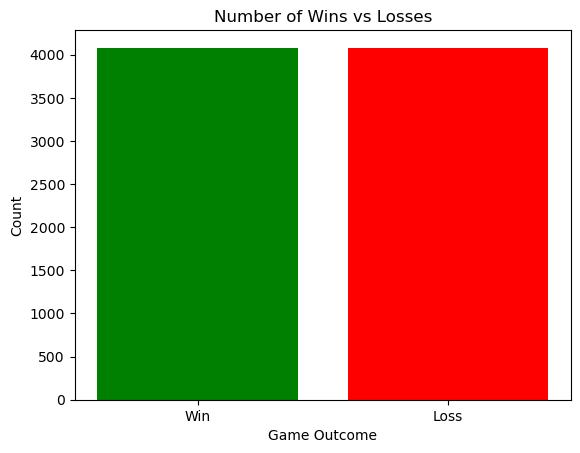

In [5]:
# Exploratory Analysis

# Count wins and losses
win_count = (df_all['win'] == 1).astype(int).sum()
loss_count = (df_all['win'] == 0).astype(int).sum()
print(f"Wins: {win_count}, Losses: {loss_count}")

# Values
categories = ['Win', 'Loss']
counts = [win_count, loss_count]

# Plot
plt.bar(categories, counts, color=['green', 'red'])
plt.title('Number of Wins vs Losses')
plt.xlabel('Game Outcome')
plt.ylabel('Count')
plt.show()

In [6]:
#Final sanity checks

# Check unique teams in recent data
current_teams = df_recent['team'].unique()
print("Number of unique teams:", len(current_teams))
print("Teams:", sorted(current_teams))

# Display win counts per team
print(df_recent.groupby('team')['win'].agg(['sum', 'count']))

# Check for any NaN values in recent data
print("Any NaNs?", df_recent.isna().sum().sum())

# Check for duplicated game-team entries in cleaned data
dup_games = df_all[df_all.duplicated(['gameId', 'team'])]
print("Duplicated rows:", len(dup_games))

Number of unique teams: 32
Teams: ['ANA', 'BOS', 'BUF', 'CAR', 'CBJ', 'CGY', 'CHI', 'COL', 'DAL', 'DET', 'EDM', 'FLA', 'LAK', 'MIN', 'MTL', 'NJD', 'NSH', 'NYI', 'NYR', 'OTT', 'PHI', 'PIT', 'SEA', 'SJS', 'STL', 'TBL', 'TOR', 'UTA', 'VAN', 'VGK', 'WPG', 'WSH']
      sum  count
team            
ANA   297   1270
BOS   495   1380
BUF   400   1275
CAR   546   1475
CBJ   314   1270
CGY   393   1280
CHI   284   1275
COL   523   1405
DAL   565   1555
DET   405   1275
EDM   604   1575
FLA   589   1620
LAK   465   1365
MIN   439   1340
MTL   370   1305
NJD   467   1360
NSH   393   1310
NYI   388   1325
NYR   496   1395
OTT   427   1305
PHI   313   1270
PIT   406   1275
SEA   414   1345
SJS   258   1275
STL   396   1305
TBL   489   1355
TOR   507   1430
UTA   392   1280
VAN   437   1345
VGK   528   1475
WPG   528   1390
WSH   430   1345
Any NaNs? 0
Duplicated rows: 0
